In [1]:
# 고전 컴퓨터비전 실습 — ③ 분할(Segmentation) 사례1: 의료영상
# [Instance(인스턴스) 방식] 개별 종양을 서로 다른 객체로 구분해 분할
#
# 인스턴스 분할은 시맨틱 분할(실습1)에서 한 걸음 더 나아가, "종양"이라는
# 같은 클래스 안에서도 "1번 종양"과 "2번 종양"을 서로 다른 객체(instance)로
# 구분해 각각 별도의 윤곽·ID를 부여한다. 두 종양이 서로 가까이 붙어있는
# 어려운 경우까지 다루기 위해 Connected Components가 아닌 Watershed
# 알고리즘으로 "닿아있는 덩어리도 갈라서" 구분한다.
#
# Clean Architecture 레이어:
#   [도메인 계층]      — 값 객체 + 추상 인터페이스. cv2/skimage 비의존.
#   [유스케이스 계층]   — InstanceSegmentationUseCase. 시맨틱 분할기 + 인스턴스
#                        분리기를 주입받아 "클래스 추출 → 개체 분리"를 조립.
#   [인프라 계층]      — Multi-Otsu(시맨틱) + Watershed(인스턴스 분리) 구현체.
#   [구성 루트]        — Colab 셀: 합성 영상 생성, DI 조립, 시각화/저장.

## 셀 1: 환경 준비

In [3]:
# !pip install opencv-python-headless scikit-image scipy matplotlib numpy --quiet
from __future__ import annotations

import numpy as np
import matplotlib
from matplotlib import font_manager as _font_manager
import glob as _glob
# 한글 폰트가 없는 환경(Colab 등)이면: !apt-get -qq install -y fonts-nanum && fc-cache -f
_candidates = _glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic.ttf") + \
    _glob.glob("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc") + \
    _glob.glob("/usr/share/fonts/**/NotoSansCJK*.ttc", recursive=True)
_korean_font_name = "sans-serif"
for _font_path in _candidates:
    try:
        _font_manager.fontManager.addfont(_font_path)
        _korean_font_name = _font_manager.FontProperties(fname=_font_path).get_name()
        break
    except Exception:
        continue
matplotlib.rcParams["font.family"] = _korean_font_name
matplotlib.rcParams["axes.unicode_minus"] = False

# ===== [도메인 계층 / Domain Layer] =====

from abc import ABC, abstractmethod
from dataclasses import dataclass


@dataclass(frozen=True)
class SemanticSegmentationResult:
    """실습1과 동일한 개념의 시맨틱 분할 결과 값 객체(이 파일은 독립 실행
    가능해야 하므로 재정의한다)."""
    original_image: np.ndarray
    class_mask: np.ndarray
    class_names: dict[int, str]

    def binary_mask_of(self, class_id: int) -> np.ndarray:
        return self.class_mask == class_id


@dataclass(frozen=True)
class InstanceSegmentationResult:
    """인스턴스 분할 결과 값 객체. instance_map은 배경=0, 개별 객체는
    1, 2, 3...처럼 서로 다른 정수 ID를 갖는 라벨 맵이다."""
    original_image: np.ndarray
    instance_map: np.ndarray
    instance_count: int
    semantic_class_name: str


class SemanticSegmenter(ABC):
    """"영상을 받아 클래스별 라벨 맵을 돌려준다"는 계약 (실습1과 동일한 역할).
    인스턴스 분할의 "1단계: 관심 클래스 픽셀 찾기"를 담당한다."""

    @abstractmethod
    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        ...


class InstanceSplitter(ABC):
    """"하나의 이진 마스크(같은 클래스 픽셀 전체)를 받아, 서로 떨어진(또는
    붙어있지만 구분 가능한) 개체별로 ID를 나눠 돌려준다"는 계약만 정의한다.
    단순 Connected Components든 Watershed든 이 인터페이스만 구현하면
    유스케이스 코드를 수정하지 않고 교체할 수 있다(OCP + DIP)."""

    @abstractmethod
    def split(self, binary_mask: np.ndarray) -> tuple[np.ndarray, int]:
        """반환값: (instance_map, instance_count)"""
        ...


# ===== [유스케이스 계층 / Use Case Layer] =====

class InstanceSegmentationUseCase:
    """"시맨틱 분할로 관심 클래스를 추출 → 인스턴스 분리기로 개체별로
    나눈다"는 2단계 파이프라인을 조립한다. 두 단계 모두 추상 인터페이스에만
    의존하므로(DIP), 알고리즘을 자유롭게 교체할 수 있다."""

    def __init__(
        self,
        semantic_segmenter: SemanticSegmenter,
        instance_splitter: InstanceSplitter,
        target_class_id: int,
    ):
        self._semantic_segmenter = semantic_segmenter
        self._instance_splitter = instance_splitter
        self._target_class_id = target_class_id

    def run(self, image: np.ndarray) -> InstanceSegmentationResult:
        semantic_result = self._semantic_segmenter.segment(image)
        target_mask = semantic_result.binary_mask_of(self._target_class_id)
        instance_map, count = self._instance_splitter.split(target_mask)

        return InstanceSegmentationResult(
            original_image=semantic_result.original_image,
            instance_map=instance_map,
            instance_count=count,
            semantic_class_name=semantic_result.class_names[self._target_class_id],
        )


# ===== [인프라/어댑터 계층 / Infrastructure Layer] =====

import cv2
from skimage.filters import threshold_multiotsu
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed


class MultiOtsuMedicalSegmenter(SemanticSegmenter):
    """실습1과 동일한 Multi-Otsu 시맨틱 분할 어댑터."""

    def __init__(self, n_classes: int = 3, blur_ksize: int = 3):
        self._n_classes = n_classes
        self._blur_ksize = blur_ksize

    def segment(self, image: np.ndarray) -> SemanticSegmentationResult:
        gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        denoised = cv2.medianBlur(gray, self._blur_ksize)
        thresholds = threshold_multiotsu(denoised, classes=self._n_classes)
        class_mask = np.digitize(denoised, bins=thresholds).astype(np.int32)
        return SemanticSegmentationResult(
            original_image=gray, class_mask=class_mask,
            class_names={0: "배경", 1: "장기", 2: "종양"},
        )


class WatershedInstanceSplitter(InstanceSplitter):
    """Watershed 기반 인스턴스 분리 어댑터. 거리 변환(distance transform)의
    극댓값을 각 객체의 "씨앗(seed)"으로 삼아 물이 차오르듯 영역을 확장시키며
    경계를 나눈다 — 두 종양이 서로 맞닿아 있어도 중심부가 떨어져 있다면
    올바르게 분리해낼 수 있다는 점이 단순 Connected Components와의 차이다."""

    def __init__(self, min_distance: int = 10):
        self._min_distance = min_distance

    def split(self, binary_mask: np.ndarray) -> tuple[np.ndarray, int]:
        mask_u8 = binary_mask.astype(np.uint8)
        if mask_u8.sum() == 0:
            return np.zeros_like(mask_u8, dtype=np.int32), 0

        distance = ndi.distance_transform_edt(mask_u8)
        coords = peak_local_max(distance, min_distance=self._min_distance, labels=mask_u8)
        seed_mask = np.zeros(distance.shape, dtype=bool)
        seed_mask[tuple(coords.T)] = True
        markers, _ = ndi.label(seed_mask)

        instance_map = watershed(-distance, markers, mask=mask_u8).astype(np.int32)
        instance_count = int(instance_map.max())
        return instance_map, instance_count


class InstanceSegmentationVisualizer:
    """시각화 전담 클래스(SRP) — 개체마다 다른 색을 입혀 원본 위에 오버레이."""

    def __init__(self, title: str):
        self._title = title
        self._palette = [
            (255, 99, 71), (65, 180, 255), (255, 215, 0),
            (154, 255, 123), (218, 112, 214), (255, 165, 0),
        ]

    def save_result(self, result: InstanceSegmentationResult, out_path: str) -> None:
        import matplotlib.pyplot as plt
        import matplotlib.patches as mpatches

        h, w = result.instance_map.shape
        colored = np.zeros((h, w, 3), dtype=np.uint8)
        for instance_id in range(1, result.instance_count + 1):
            color = self._palette[(instance_id - 1) % len(self._palette)]
            colored[result.instance_map == instance_id] = color

        base_rgb = cv2.cvtColor(result.original_image, cv2.COLOR_GRAY2RGB) \
            if result.original_image.ndim == 2 else result.original_image
        overlay = base_rgb.copy()
        mask_any = result.instance_map > 0
        overlay[mask_any] = (0.45 * base_rgb[mask_any] + 0.55 * colored[mask_any]).astype(np.uint8)

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.suptitle(self._title, fontsize=14, fontweight="bold")

        axes[0].imshow(result.original_image, cmap="gray" if result.original_image.ndim == 2 else None)
        axes[0].set_title("1. 원본 (합성 CT 단면)")
        axes[0].axis("off")

        axes[1].imshow(overlay)
        axes[1].set_title(f"2. Instance 분할 결과 ({result.semantic_class_name} {result.instance_count}개 개별 구분)")
        axes[1].axis("off")
        legend_patches = [
            mpatches.Patch(color=np.array(self._palette[i % len(self._palette)]) / 255,
                            label=f"{result.semantic_class_name} #{i + 1}")
            for i in range(result.instance_count)
        ]
        axes[1].legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)

        plt.tight_layout()
        plt.savefig(out_path, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"저장 완료: {out_path} / 구분된 개체 수: {result.instance_count}")


# ===== [구성 루트 / Composition Root — Colab 실행 코드] =====

## 셀 2: 합성 CT 단면 생성 (실습1과 동일한 생성 로직 — 종양 2개 포함)

In [4]:
def make_synthetic_ct_slice(size: int = 256, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    canvas = np.full((size, size), 25, dtype=np.float64)

    yy, xx = np.ogrid[:size, :size]
    organ_mask = ((xx - 128) / 85) ** 2 + ((yy - 128) / 100) ** 2 <= 1
    canvas[organ_mask] = 120

    tumor_centers = [(95, 110), (160, 145)]
    tumor_radii = [18, 14]
    for (cy, cx), r in zip(tumor_centers, tumor_radii):
        tumor_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
        canvas[tumor_mask] = 215

    noise = rng.normal(0, 6, size=canvas.shape)
    canvas = np.clip(canvas + noise, 0, 255).astype(np.uint8)
    return canvas


ct_image = make_synthetic_ct_slice(size=256, seed=42)
print("합성 CT 영상 크기:", ct_image.shape)

합성 CT 영상 크기: (256, 256)


## 셀 3: 구체 어댑터 생성 + 의존성 주입(DIP)

In [5]:
semantic_segmenter: SemanticSegmenter = MultiOtsuMedicalSegmenter(n_classes=3, blur_ksize=3)
instance_splitter: InstanceSplitter = WatershedInstanceSplitter(min_distance=10)

use_case = InstanceSegmentationUseCase(
    semantic_segmenter=semantic_segmenter,
    instance_splitter=instance_splitter,
    target_class_id=2,  # "종양" 클래스만 개체별로 분리
)

## 셀 4: 실행

In [6]:
result = use_case.run(ct_image)
print(f"구분된 '{result.semantic_class_name}' 개체 수: {result.instance_count}")

구분된 '종양' 개체 수: 2


## 셀 5: 결과 시각화 및 저장

/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1604/1147668545.py:197: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
 

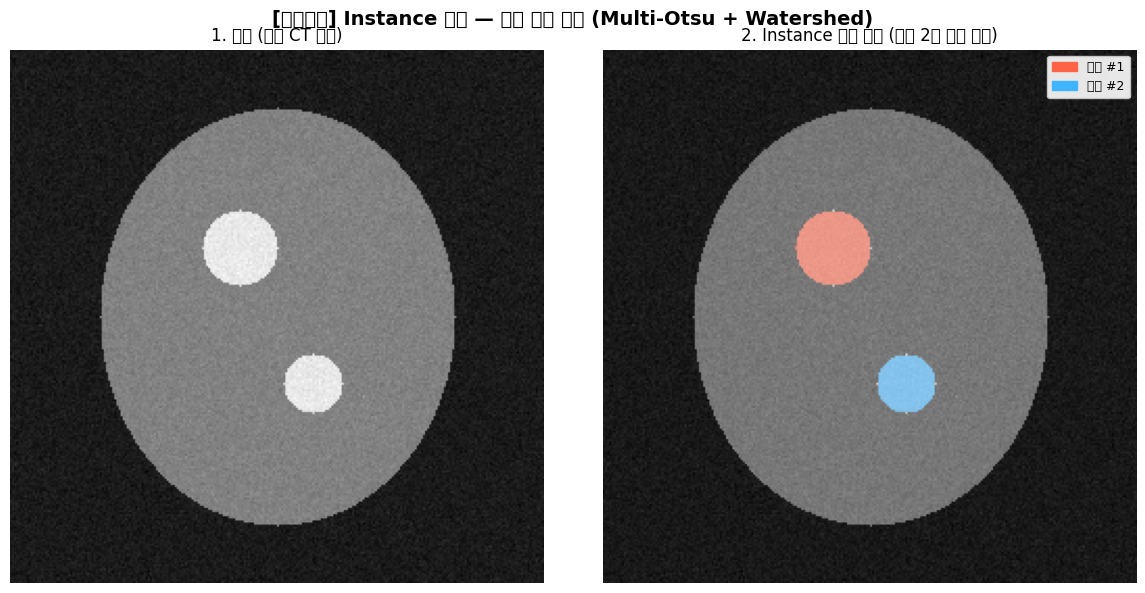

저장 완료: medical_instance_result.png / 구분된 개체 수: 2


In [8]:
visualizer = InstanceSegmentationVisualizer(
    title="[의료영상] Instance 분할 — 개별 종양 구분 (Multi-Otsu + Watershed)"
)
visualizer.save_result(result, "medical_instance_result.png")

## 셀 6: (참고) Semantic vs Instance 비교 요약

In [7]:
print("\n=== Semantic vs Instance 비교 ===")
print("Semantic 분할: '종양'이라는 클래스 1개로만 표시 (몇 개인지 알 수 없음)")
print(f"Instance 분할: 서로 다른 종양 {result.instance_count}개를 각각 "
      f"'종양 #1', '종양 #2'...로 구분 (개수·위치·크기를 개별적으로 추적 가능)")


=== Semantic vs Instance 비교 ===
Semantic 분할: '종양'이라는 클래스 1개로만 표시 (몇 개인지 알 수 없음)
Instance 분할: 서로 다른 종양 2개를 각각 '종양 #1', '종양 #2'...로 구분 (개수·위치·크기를 개별적으로 추적 가능)
